In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import random
import os
import matplotlib.pyplot as plt
import simo
from simo import load_data, process_anndata, find_marker, alignment_1_batch, assign_coord_1, alignment_2, assign_coord_2
from simo.regulation import regulation_analysis, spatial_regulation
from simo import sdplot, sfplot, cor_plot, module_vilolin_plot, module_dot_plot, module_pca_plot, module_spatial_plot, module_heatmap_plot, plot_3d

import warnings
warnings.filterwarnings("ignore")



In [7]:



sc_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
st_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
rna = load_data(sc_data_path)
st = load_data(st_data_path)
spot_cluster=pd.read_csv('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/Spot_cluster_zztry.txt',sep='\t')


In [8]:
st.obs['seurat_clusters']=spot_cluster['cluster'].astype('category').values

In [9]:
st_processed = process_anndata(st,neighbors=True,umap=True,n_comps=100)

Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Performing PCA...
Calculating neighbors based on cosine metric...
Performing UMAP...
Processing completed.


In [10]:
st_processed.obsm['reduction']=st_processed.obsm['X_pca']

In [11]:
rna_processed = process_anndata(rna,neighbors=True,umap=True,n_comps=100)

Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Performing PCA...
Calculating neighbors based on cosine metric...
Performing UMAP...
Processing completed.


In [12]:
rna_processed.obsm['reduction']=rna_processed.obsm['X_pca']

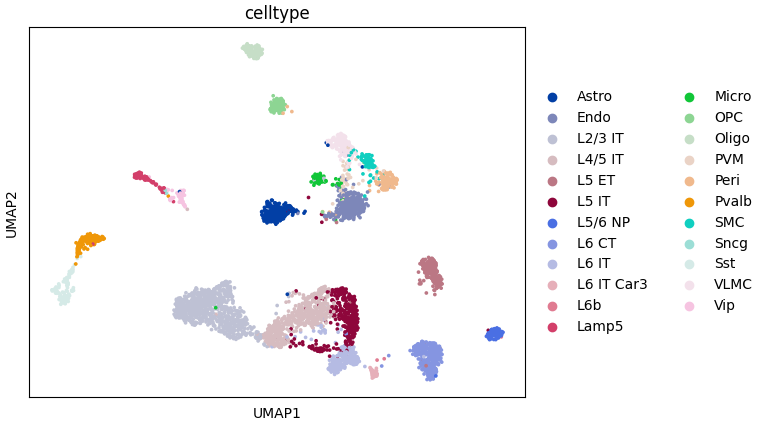

In [13]:
sc.pl.umap(rna_processed,color=['celltype'])

In [14]:
gene_list1_params = {
    "gene_selection_method": 'deg',
    "deg_num": 100,
    "marker1_by": 'seurat_clusters',
    "marker2_by": 'celltype',
}
gene_list1 = find_marker(st_processed, 
                         rna_processed, 
                         **gene_list1_params
                        )

Number of common genes: 254


In [15]:
alignment_1_params = {
    "alpha": 0.1,
    "G_init": None,
    "p_distribution": None,
    "q_distribution": None,
    "aware_st_label": "seurat_clusters",
    "aware_sc_label": "celltype",
}
out1 = alignment_1_batch(adata1=st_processed[:, gene_list1],
                   adata2=rna_processed[:, gene_list1],
                   **alignment_1_params)

Splitting dataset into 5 subsets...
Running alignment on subset 1/5...
Calculating dissimilarity using euclidean distance on scaled data...
Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Processing completed.
Constructing connectivity...
k = 10
aware_st = True
aware power = 2
aware_sc = True
aware power = 2
Running OT...
alpha = 0.1
OT done!
Running alignment on subset 2/5...
Calculating dissimilarity using euclidean distance on scaled data...
Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Processing completed.
Constructing connectivity...
k = 10
aware_st = True
aware power = 2
aware_sc = True
aware power = 2
Running OT...
alpha = 0.1
OT done!
Running alignment on subset 3/5...
Calculating dissimilarity using euclidean distanc

In [16]:
out1.to_csv('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/SMIO/Alignment_out1_zztry.csv')

In [17]:
assign_coord_1_params = {
    "non_zero_probabilities": True,
    "no_repeated_cells": True,
    "top_num": 5,
    "expected_num": None,
    "pos_random": False,
    "layer": 'data'
}

st_processed.obs['type']=st_processed.obs['seurat_clusters']


In [19]:
rna_processed

AnnData object with n_obs × n_vars = 4198 × 254
    obs: 'x_coord', 'y_coord', 'slice_id', 'celltype', 'leiden', 'type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'celltype_colors', 'leiden'
    obsm: 'X_pca', 'X_umap', 'reduction'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'distances', 'connectivities'

In [20]:
sc.tl.leiden(rna_processed,resolution=1)
rna_processed.obs['type']=rna_processed.obs['celltype']

map1 = assign_coord_1(adata1=st_processed[:, gene_list1], 
                      adata2=rna_processed[:, gene_list1], 
                      out_data=out1,
                      **assign_coord_1_params)

Assigning spatial coordinates to cells...
random = False
Maximum number of cells assigned to spots: 5
There are 424 spots and 424 of them were assigned cells.
Assignment done!


In [ ]:
map1.to_csv('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/SMIO/Location_map1_zztry.csv')

In [22]:
rna_mapped = rna_processed[map1.cell]
rna_mapped.obsm['spatial'] = map1[['Cell_xcoord','Cell_ycoord']].values
rna_mapped.obs['spot'] = map1['spot'].tolist()
rna_mapped.obs['spot_type'] = map1['spot_type'].tolist()

In [23]:
# 保存为 .h5ad 文件（推荐格式）
sc.write("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/SMIO/rna_mapped_zztry.h5ad", rna_mapped)

In [24]:
pca_df = pd.DataFrame(
    rna_processed.obsm['X_pca'][:, 1:30],
    index=rna_processed.obs_names,  # 应该是obs_names，而不是var_names
    columns=[f'LSI_{i}' for i in range(2, 31)]
)

In [25]:
pca_df.to_csv('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/spaTrio/emb_zztry.csv')